### Machine Learning by Regression

In [1]:
import pandas as pd
import numpy as np

#### Data Preparation

In [2]:
df = pd.read_csv('data.csv')

In [3]:
# Change the names of the columns to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
string_columns = list(df.dtypes[df.dtypes == 'str'].index)
string_columns

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [5]:
# Change the values of string columns to lowercase and replace spaces with underscores
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [6]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


#### Exploratory Data Analysis

In [7]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print(df[col].nunique())
    print()

make
<StringArray>
[          'bmw',          'audi',          'fiat', 'mercedes-benz',
      'chrysler',        'nissan',         'volvo',         'mazda',
    'mitsubishi',       'ferrari',    'alfa_romeo',        'toyota',
       'mclaren',       'maybach',       'pontiac',       'porsche',
          'saab',           'gmc',       'hyundai',      'plymouth',
         'honda',    'oldsmobile',        'suzuki',          'ford',
      'cadillac',           'kia',       'bentley',     'chevrolet',
         'dodge',   'lamborghini',       'lincoln',        'subaru',
    'volkswagen',        'spyker',         'buick',         'acura',
   'rolls-royce',      'maserati',         'lexus',  'aston_martin',
    'land_rover',         'lotus',      'infiniti',         'scion',
       'genesis',        'hummer',         'tesla',       'bugatti']
Length: 48, dtype: str
48

model
<StringArray>
[  '1_series_m',     '1_series',          '100',   '124_spider',
    '190-class',     '2_series',         

##### Distribution of Price

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

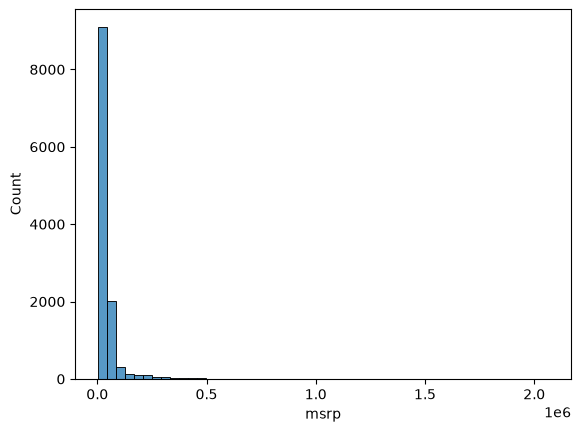

In [9]:
sns.histplot(df.msrp, bins=50)
# Not a good idea to plot the whole range of msrp, because there are some outliers

<Axes: xlabel='msrp', ylabel='Count'>

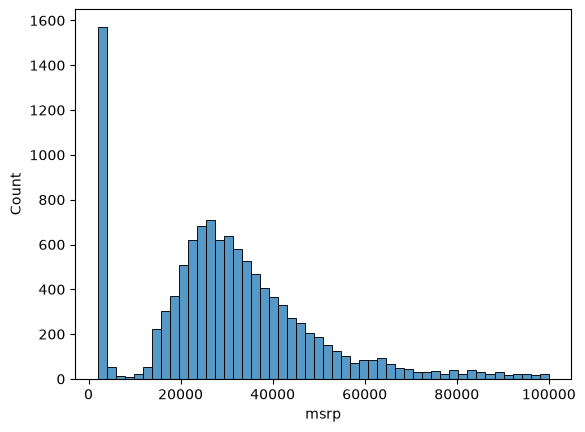

In [10]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

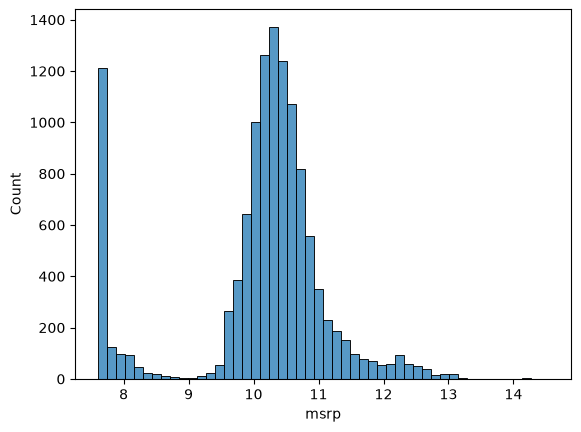

In [11]:
# Use logarithmic scale to see the distribution better
price_logs = np.log1p(df.msrp)

sns.histplot(price_logs, bins=50)

##### Missing Values

In [12]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

#### Setting up the Validation Framework

In [13]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [14]:
n

11914

In [15]:
n_train, n_val, n_test

(7150, 2382, 2382)

In [16]:
# Split the data into train, validation, and test sets. Use copy() to avoid changing the original dataframe when we change the new dataframes.
df_train = df.iloc[:n_train].copy()
df_val = df.iloc[n_train:n_train+n_val].copy()
df_test = df.iloc[n_train+n_val:].copy()

In [17]:
# Instead of splitting the data sequentially, we can shuffle the data first and then split it. This will help us avoid any potential bias in the data.
idx = np.arange(n)

In [18]:
np.random.seed(2)
np.random.shuffle(idx) # Shuffle the indices to randomize the data

In [19]:
df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train+n_val]].copy()
df_test = df.iloc[idx[n_train+n_val:]].copy()

In [20]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [21]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [22]:
# Reset the indices of the dataframes to avoid any potential issues with indexing later on
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [23]:
# Create the target variable for the regression model. We will use the logarithm of the MSRP as the target variable, because the distribution of MSRP is skewed and taking the logarithm will help us to normalize it.
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [24]:
# Delete the target variable from the dataframes, because we don't want to use it as a feature in our model.
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [25]:
len(y_train), len(y_val), len(y_test)

(7150, 2382, 2382)

#### Linear Regression

In [26]:
# We will use the following features for our regression model: engine_hp, city_mpg, and popularity. Let's check the values of these features for the 10th row of the training set.
df_train.iloc[10][["engine_hp", "city_mpg", "popularity"]]

engine_hp     453.0
city_mpg         11
popularity       86
Name: 10, dtype: object

In [27]:
xi = df_train.iloc[10][["engine_hp", "city_mpg", "popularity"]].values # Get the values of the features for the 10th row of the training set
w0 = 7.17 # Bias term, this value is randomly chosen, we will learn the optimal value of this parameter during training
w = np.array([0.01, 0.04, 0.002]) # Weights for the features, these values are randomly chosen, we will learn the optimal values of these parameters during training


In [28]:
# Simple linear regression model: y = w0 + w1*x1 + w2*x2 + w3*x3

def linear_regression(xi):
    n = len(xi)
    
    pred = w0 + np.dot(w, xi) # Calculate the predicted value using the linear regression formula
    return pred

linear_regression(xi)

np.float64(12.312000000000001)

In [29]:
# Reverse the log1p transformation to get the predicted MSRP value
np.expm1(linear_regression(xi))

np.float64(222347.22211010658)

In [30]:
# Check the real MSRP value for the 10th row of the training set
np.expm1(y_train[10])

np.float64(479775.00000000006)

In [31]:
# Linear regression vectorized implementation: y = w0 + w1*x1 + w2*x2 + w3*x3
def linear_regression_vectorized(X):
    return w0 + np.dot(X, w) # Calculate the predicted values for all rows in the input matrix X using the linear regression formula

In [32]:
w_new = [w0] + list(w) # Create a new list of weights that includes the bias term w0 and the weights for the features w
w_new

[7.17, np.float64(0.01), np.float64(0.04), np.float64(0.002)]

In [33]:
def linear_regression_vectorized(X):
    X = [1] + list(X) # Add a column of ones to the input matrix X to account for the bias term w0
    return np.dot(X, w_new) # Calculate the predicted values for all rows in the input matrix X using the linear regression formula

In [34]:
linear_regression_vectorized(xi)

np.float64(12.312)

In [35]:
w0 = 7.17
w = np.array([0.01, 0.04, 0.002])
w_new = [w0] + list(w) # Create a new list of weights that includes the bias term w0 and the weights for the features w

In [36]:
# Get three instances from the training set to test the vectorized implementation of the linear regression model
x1 = np.append([1], df_train.iloc[10][["engine_hp", "city_mpg", "popularity"]].values)
x2 = np.append([1], df_train.iloc[20][["engine_hp", "city_mpg", "popularity"]].values)
x3 = np.append([1], df_train.iloc[30][["engine_hp", "city_mpg", "popularity"]].values)

x1

array([1, np.float64(453.0), np.int64(11), np.int64(86)], dtype=object)

In [37]:
X = np.array([x1, x2, x3]) # Create a matrix of the three instances to test the vectorized implementation of the linear regression model
X

array([[1, np.float64(453.0), np.int64(11), np.int64(86)],
       [1, np.float64(280.0), np.int64(16), np.int64(5657)],
       [1, np.float64(302.0), np.int64(18), np.int64(617)]], dtype=object)

In [38]:
def linear_regression(X):
    return np.dot(X, w_new) # Calculate the predicted values for all rows in the input matrix X using the linear regression formula

In [39]:
linear_regression(X)

array([np.float64(12.312), np.float64(21.924), np.float64(12.144)],
      dtype=object)

#### Training a linear regression model

In [40]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0]) # Create a column of ones to account for the bias term w0
    X = np.column_stack((ones, X)) # Add the column of ones to the input matrix X
    
    XTX = np.dot(X.T, X) # Calculate the dot product of the transpose of X and X
    XTX_inv = np.linalg.inv(XTX) # Calculate the inverse of the dot product of the transpose of X and X
    w_full = np.dot(XTX_inv, np.dot(X.T, y)) # Calculate the weights for the linear regression model using the normal equation
    
    return w_full[0], w_full[1:] # Return the bias term w0 and the weights for the features w

In [41]:
# Test it
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [42]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [43]:
train_linear_regression(X, y)

(np.float64(25844.754055766796),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

#### Car Price Baseline Model

In [44]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [45]:
# Choose the columns engine_hp, engine_cylinders, highway_mpg, city_mpg, and popularity as the features for the regression model
base = ["engine_hp", "engine_cylinders", "highway_mpg", "city_mpg", "popularity"]

df_train[base].head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657


##### Value Extraction

In [46]:
# Extract the values to use as the input matrix X for the regression model
X_train = df_train[base].values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

##### Missing Values

In [47]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [48]:
# Fill missing values with zero. Not a good idea, but we will do it for this example.
X_train = df_train[base].fillna(0).values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [49]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [50]:
# Train the linear regression model using the training set
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.927257388069929),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [51]:
# Predict the target variable
y_pred = w0 + np.dot(X_train, w)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

##### Plotting Model Performance

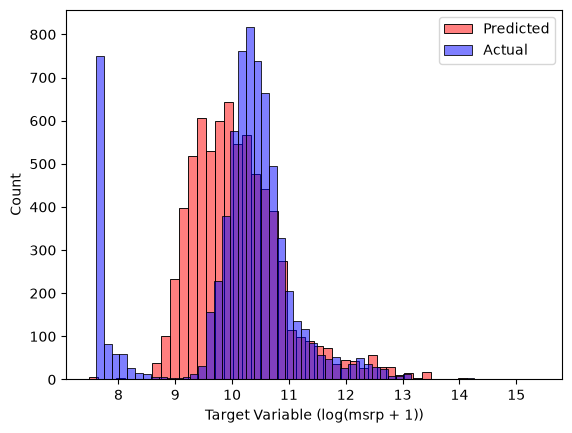

In [52]:
# alpha : transparency of the histogram bars
sns.histplot(y_pred, color="red", alpha=0.5, bins=50)
sns.histplot(y_train, color="blue", alpha=0.5, bins=50)

# add legend to the plot and numerical labels to the x and y axes
plt.xlabel("Target Variable (log(msrp + 1))")
plt.legend(["Predicted", "Actual"])

#### Root Mean Squared Error – RMSE

In [53]:
# RMSE is the square root of the mean squared error
def rmse(y, y_pred):
    error = y - y_pred
    mse = np.mean(error ** 2)
    return np.sqrt(mse)

In [54]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

##### Validating the Model

In [55]:
# This function prepares the input matrix X for the regression model by selecting the numerical features, filling missing values with zero, and extracting the values as a numpy array.
def prepare_X(df):
    df_num = df[base].copy() # Create a copy of the dataframe with only the numerical features
    df_num = df_num.fillna(0) # Fill missing values with zero. Not a good idea, but we will do it for this example.
    X = df_num.values # Extract the values to use as the input matrix X for the regression model
    return X

In [56]:
# Now we can use this function to prepare the input matrix X for the validation and test sets as well. 
# This will ensure that we are using the same features and handling missing values in the same way for all three datasets.

# Training part:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

# Validation part:
X_val = prepare_X(df_val)
y_pred = w0 + np.dot(X_val, w)

# Evaluation part, compare test and validation RMSE
print("Validation RMSE:", rmse(y_val, y_pred))

# We see that the RMSE values are quite similar, which indicates that our model is not overfitting the training data.
# This is a good sign, as it suggests that our model is able to generalize well to new data.

Validation RMSE: 0.7616530991301617


#### Simple Feature Engineering

In [57]:
# Add a new feature age
2026 - df_train.year

0       18
1       14
2       10
3       35
4        9
        ..
7145    11
7146    11
7147    11
7148    12
7149     9
Name: year, Length: 7150, dtype: int64

In [58]:
base = ["engine_hp", "engine_cylinders", "highway_mpg", "city_mpg", "popularity"]

def prepare_X(df):
    df = df.copy() # Create a copy of the dataframe to avoid changing the original dataframe
    df["age"] = 2026 - df.year # Add a new feature age
    features = base + ["age"] # Add the new feature age to the list of features
    
    df_num = df[features]
    df_num = df_num.fillna(0) # Fill missing values with zero. Not a good idea, but we will do it for this example.
    
    X = df_num.values # Extract the values to use as the input matrix X for the regression model
    return X

X_train = prepare_X(df_train)
X_train

array([[ 148.,    4.,   33.,   24., 1385.,   18.],
       [ 132.,    4.,   32.,   25., 2031.,   14.],
       [ 148.,    4.,   37.,   28.,  640.,   10.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.,   11.],
       [ 563.,   12.,   21.,   13.,   86.,   12.],
       [ 200.,    4.,   31.,   22.,  873.,    9.]], shape=(7150, 6))

In [59]:
# Train a new model
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + np.dot(X_val, w)

rmse(y_val, y_pred)

np.float64(0.5172055461058336)

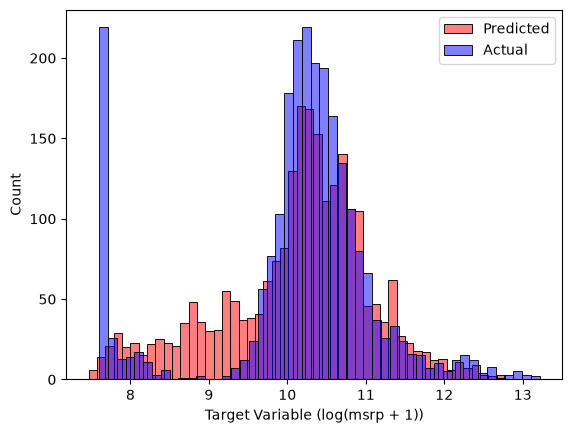

In [60]:
# We saw an improvement in the RMSE value after adding the new feature age.
# This suggests that the new feature is useful for predicting the target variable and has improved the performance of our regression model.

# alpha : transparency of the histogram bars
sns.histplot(y_pred, color="red", alpha=0.5, bins=50)
sns.histplot(y_val, color="blue", alpha=0.5, bins=50)

# add legend to the plot and numerical labels to the x and y axes
plt.xlabel("Target Variable (log(msrp + 1))")
plt.legend(["Predicted", "Actual"])

#### Categorical Variables

In [61]:
# One value looks like numerical, but it is actually categorical. Let's check the unique values of the feature "number_of_doors" in the training set.
# We will use this feature as a categorical variable in our regression model.

df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [62]:
df_train.number_of_doors.unique()

array([ 2.,  4.,  3., nan])

In [63]:
# Typical way of encoding categorical variables is to use one-hot encoding. 
# This means that we will create a new binary feature for each unique value of the categorical variable. 

def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df["age"] = 2026 - df.year # Add a new feature age
    features.append("age") # Add the new feature age to the list of features
    
    for v in [2, 3, 4]:
        df[f"num_doors_{v}"] = (df.number_of_doors == v).astype(int) # Create a new binary feature for each unique value of the categorical variable number_of_doors
        features.append(f"num_doors_{v}") # Add the new binary feature to the list of features
        
    df_num = df[features]
    df_num = df_num.fillna(0) # Fill missing values with zero.
    
    X = df_num.values # Extract the values to use as the input matrix X for the regression model
    return X

prepare_X(df_train)
    

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   1.],
       [563.,  12.,  21., ...,   0.,   0.,   1.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(7150, 9))

In [64]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + np.dot(X_val, w)

rmse(y_val, y_pred)

# We see a slight improvement in the RMSE value after adding the new categorical feature number_of_doors.

np.float64(0.5157995641502718)

In [65]:
# Try "make" feature as a categorical variable.

df.make.unique()  

<StringArray>
[          'bmw',          'audi',          'fiat', 'mercedes-benz',
      'chrysler',        'nissan',         'volvo',         'mazda',
    'mitsubishi',       'ferrari',    'alfa_romeo',        'toyota',
       'mclaren',       'maybach',       'pontiac',       'porsche',
          'saab',           'gmc',       'hyundai',      'plymouth',
         'honda',    'oldsmobile',        'suzuki',          'ford',
      'cadillac',           'kia',       'bentley',     'chevrolet',
         'dodge',   'lamborghini',       'lincoln',        'subaru',
    'volkswagen',        'spyker',         'buick',         'acura',
   'rolls-royce',      'maserati',         'lexus',  'aston_martin',
    'land_rover',         'lotus',      'infiniti',         'scion',
       'genesis',        'hummer',         'tesla',       'bugatti']
Length: 48, dtype: str

In [66]:
# Too much unique values of "make", check the most popular values of the feature "make" in the training set.
df.make.value_counts().head()


make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [67]:
# To get the actual values of the most popular makes, we can use the index of the value_counts() method.
df.make.value_counts().head().index

Index(['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'], dtype='str', name='make')

In [68]:
# Wrap it into a list
makes = list(df.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [69]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df["age"] = 2026 - df.year # Add a new feature age
    features.append("age") # Add the new feature age to the list of features
    
    for v in [2, 3, 4]:
        df[f"num_doors_{v}"] = (df.number_of_doors == v).astype(int) # Create a new binary feature for each unique value of the categorical variable number_of_doors
        features.append(f"num_doors_{v}") # Add the new binary feature to the list of features
        
    for make in makes:
        df[f"make_{make}"] = (df.make == make).astype(int) # Create a new binary feature for each unique value of the categorical variable make
        features.append(f"make_{make}") # Add the new binary feature to the list of features
        
    df_num = df[features]
    df_num = df_num.fillna(0) # Fill missing values with zero.
    
    X = df_num.values # Extract the values to use as the input matrix X for the regression model
    return X

In [70]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + np.dot(X_val, w)

rmse(y_val, y_pred)

np.float64(0.5076038849556801)

In [71]:
# The model improved again
# Lets add all categorical features to the model and see if we can improve the RMSE value even further.

categorical_variables = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 
    'market_category', 'vehicle_size', 'vehicle_style']

# The dictionary category will contain for each of the categories top 5 most common ones
categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)
    
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [72]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df["age"] = 2026 - df.year # Add a new feature age
    features.append("age") # Add the new feature age to the list of features
    
    for v in [2, 3, 4]:
        df[f"num_doors_{v}"] = (df.number_of_doors == v).astype(int) # Create a new binary feature for each unique value of the categorical variable number_of_doors
        features.append(f"num_doors_{v}") # Add the new binary feature to the list of features
        
    for c, values in categories.items():
        for v in values:
            df[f"{c}_{v}"] = (df[c] == v).astype(int) # Create a new binary feature for each unique value of the categorical variable
            features.append(f"{c}_{v}") # Add the new binary feature to the list of features
        
    df_num = df[features]
    df_num = df_num.fillna(0) # Fill missing values with zero.
    
    X = df_num.values # Extract the values to use as the input matrix X for the regression model
    return X

In [73]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + np.dot(X_val, w)

print(rmse(y_val, y_pred))
print("RMSE value is increased a lot after adding all categorical features to the model. \nIt turns out that adding too many categorical features was not a good idea.")

29.076529866049587
RMSE value is increased a lot after adding all categorical features to the model. 
It turns out that adding too many categorical features was not a good idea.


#### Regularization

In [74]:
# Sometimes the inverse of the matrix X^T * X does not exist.
# This can happen when the matrix is not full rank, which means that some of the columns are linearly dependent.

# Example:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5]
]

X = np.array(X)
X

array([[4, 4, 4],
       [3, 5, 5],
       [5, 1, 1],
       [5, 4, 4],
       [7, 5, 5],
       [4, 5, 5]])

In [75]:
XTX = np.dot(X.T, X)
XTX

array([[140, 111, 111],
       [111, 108, 108],
       [111, 108, 108]])

In [76]:
try:
    np.linalg.inv(XTX)
except:
    print("Matrix is not invertible")

Matrix is not invertible


In [77]:
# Lets add a few noise
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.0000001]
]

X = np.array(X)
y = [1, 2, 3, 1, 2, 3]

XTX = np.dot(X.T, X)
XTX

array([[140.       , 111.       , 111.0000004],
       [111.       , 108.       , 108.0000005],
       [111.0000004, 108.0000005, 108.000001 ]])

In [78]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 3.92646538e-02, -1.54615164e+05,  1.54615122e+05],
       [-1.54615170e+05,  3.51843724e+13, -3.51843721e+13],
       [ 1.54615129e+05, -3.51843721e+13,  3.51843718e+13]])

In [79]:
# Lets check vector w, which is the weights of the linear regression model.
w = XTX_inv @ X.T @ y
w

array([ 3.25115862e-01, -4.41093100e+06,  4.41093113e+06])

In [80]:
# Second and third elements of w are very large, it will lead the model performing poorly

# Adding a small number to the diagonal
# helps to control. So the numbers of w become smaller
XTX = [
    [1.0001, 2, 2],
    [2, 1.0001, 1.0000001],
    [2, 1.0000001, 1.0001]
]
XTX = np.array(XTX)
np.linalg.inv(XTX)

array([[-3.33366691e-01,  3.33350007e-01,  3.33350007e-01],
       [ 3.33350007e-01,  5.00492166e+03, -5.00508835e+03],
       [ 3.33350007e-01, -5.00508835e+03,  5.00492166e+03]])

In [81]:
# Add larger number to the diagonal
XTX = [
    [1.01, 2, 2],
    [2, 1.01, 1.0000001],
    [2, 1.0000001, 1.01]
]

XTX = np.array(XTX)
np.linalg.inv(XTX)

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [82]:
# Reimplement the train_linear_regression function to add a small number to the diagonal of the matrix X^T * X before calculating its inverse. This will help to control the size of the weights and improve the performance of the model.
def train_linear_regression(X, y, alpha=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X)) # Add a column of ones to the input matrix X to account for the bias term w0
    
    XTX = np.dot(X.T, X) # Calculate the dot product of the transpose of X and X
    XTX += alpha * np.eye(XTX.shape[0]) # Add a small number
    
    XTX_inv = np.linalg.inv(XTX) # Calculate the inverse of the dot product of the transpose of X and X
    w_full = np.dot(XTX_inv, np.dot(X.T, y)) # Calculate
    
    return w_full[0], w_full[1:] # Return the bias term w0 and the weights for the features w

In [83]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train, 0.01)

X_val = prepare_X(df_val)
y_pred = w0 + np.dot(X_val, w)

rmse(y_val, y_pred)

# This is the best result we have got so far. The RMSE value is lower than the previous models, which indicates that our model is performing better on the validation set.

np.float64(0.4565228842179254)

#### Tuning the Model

In [84]:
# We will try to find  the best value of alpha by trying different values and checking the RMSE value for each one.
for alpha in [0.0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train, alpha)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + np.dot(X_val, w)
    
    print(f"alpha: {alpha}, RMSE: {rmse(y_val, y_pred)}")

alpha: 0.0, RMSE: 29.076529866049587
alpha: 1e-05, RMSE: 0.4565170093519796
alpha: 0.0001, RMSE: 0.45651707092290117
alpha: 0.001, RMSE: 0.45651759742126874
alpha: 0.01, RMSE: 0.4565228842179254
alpha: 0.1, RMSE: 0.4565787362481443
alpha: 1, RMSE: 0.4573556036282816
alpha: 10, RMSE: 0.47279617120829687


### Full Train

#### Combining Datasets

In [87]:
df_full_train = pd.concat([df_train, df_val], ignore_index=True) # Combine the training and validation sets to create a full training set
# Ignore index to avoid duplicate indices in the new dataframe

In [92]:
X_full_train = prepare_X(df_full_train)

In [93]:
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [94]:
y_full_train = np.concatenate([y_train, y_val]) # Combine the target variable for the training and validation sets to create a full target variable for the full training set

wo, w = train_linear_regression(X_full_train, y_full_train, 0.001)

X_test = prepare_X(df_test)
y_pred = wo + np.dot(X_test, w)

rmse(y_test, y_pred)

np.float64(0.4517749619057504)

In [95]:
car = df_test.iloc[20].to_dict() # Get the 10th row of the test set as a dictionary to use as input for the prediction
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [96]:
df_small = pd.DataFrame([car]) # Create a new dataframe with the single row of data to use as input for the prediction
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [97]:
X_small = prepare_X(df_small)

y_pred = wo + np.dot(X_small, w) # Predict the target variable for the single row of data using the trained model
y_pred = y_pred[0] # Get the first element of the predicted value, because the output of the dot product is a 1D array with a single element
y_pred

np.float64(10.462650515418279)

In [98]:
np.expm1(y_pred) # Reverse the log1p transformation to get the predicted MSRP value for the single row of data

np.float64(34983.15471097816)

In [99]:
np.expm1(y_test[20])

np.float64(35000.00000000001)